# 02 — Prétraitement

**Objectif.** Transformer les données brutes NILMTK en séquences propres, alignées et
prêtes à fenêtrer pour les modèles (notebooks 04+). 

**Décisions tranchées ici (détaillées en §1) :**
- **Résolution** : rééchantillonnage commun à **6 s** pour UK-DALE *et* REDD.
- **Appareils cibles** : fridge (charge froide regroupée), washing machine, dish washer,
  microwave, kettle (UK-DALE uniquement). Résolution des alias de nommage.
- **Seuils ON/OFF** : nos propres seuils constants par appareil (ceux de NILMTK étaient
  incohérents entre maisons — cf. notebook 01).
- **Fenêtre** : 599 points (Seq2Point, Zhang 2018), appliquée **à la volée**.
- **Normalisation** : moyenne/écart-type calculés **sur le train uniquement**, par dataset.
- **Trous** : on découpe en segments continus sans NaN ; aucune imputation.

**Extraction du signal (point technique important).** NILMTK, quand on lui demande un
rééchantillonnage (`sample_period=6`), génère une grille régulière couvrant toute la plage
temporelle et y insère des NaN partout où le signal natif a une coupure d'enregistrement.
Sur REDD, dont les enregistrements sont fragmentés, cela produit ~50 % de NaN même si le
signal natif est à 0 % de NaN. On extrait donc chaque série à sa **résolution native**, on
retire les NaN, puis on re-binne à 6 s **avec pandas** (qui ne crée pas de bins fantômes).
Résultat : UK-DALE reste à ~0 % de NaN ; REDD reflète ses **vrais** trous d'enregistrement
(incompressibles), proprement gérés par la segmentation de l'étage B.

**Pipeline en deux étages :**
1. **Étage A** — extraction + alignement par maison → `data/processed/aligned/*.pkl` (caché).
2. **Étage B** — concaténation en séquences par appareil + offsets → `data/processed/seq2point/*.npz`.

**Pourquoi ne pas sauvegarder les fenêtres ?** Deux fenêtres Seq2Point voisines partagent 598/599 points. Les matérialiser multiplierait le stockage par ~600. On sauvegarde les séquences 1D + offsets, et on fenêtre à la volée dans le `Dataset` PyTorch (§7).

## 0 — Configuration et imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

import nilmtk
from nilmtk import DataSet

print(f"NILMTK {nilmtk.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

NILMTK 0.4.0.dev1+git.1b324df | pandas 2.2.3 | numpy 2.4.5


In [2]:
DATA_DIR = Path("../data")
DATASETS = {"UK-DALE": DATA_DIR / "ukdale.h5", "REDD": DATA_DIR / "redd.h5"}

PROC_DIR    = DATA_DIR / "processed"
ALIGNED_DIR = PROC_DIR / "aligned"
SEQ_DIR     = PROC_DIR / "seq2point"
for d in (ALIGNED_DIR, SEQ_DIR):
    d.mkdir(parents=True, exist_ok=True)

EXPLO_CONFIG = Path("../outputs/exploration/exploration_config.json")
if EXPLO_CONFIG.exists():
    cfg01 = json.load(open(EXPLO_CONFIG))
    print("Config 01 chargee :", EXPLO_CONFIG)
else:
    cfg01 = {}
    print("Config 01 absente -> fallback sur les valeurs par defaut")

datasets = {}
for name, path in DATASETS.items():
    if path.exists():
        datasets[name] = DataSet(str(path))
        print(f"OK   {name}")
    else:
        print(f"MISS {name} : {path}")

Config 01 chargee : ..\outputs\exploration\exploration_config.json
OK   UK-DALE
OK   REDD


## 1 — Paramètres de prétraitement (décisions documentées)

**Résolution (6 s).** UK-DALE est nativement à 6 s ; REDD à 1 s (mains) / 3 s (sous-compteurs).
On rééchantillonne **tout à 6 s** (extraction native + re-bin pandas — cf. titre). Une fenêtre
de 599 points couvre alors la *même durée physique* (~1 h) dans les deux datasets, condition
d'une comparaison inter-dataset honnête ; et 6 s est la résolution de référence Seq2Point.

**Fenêtre (599).** Référence Seq2Point (Zhang et al. 2018). À 6 s → ~1 h de contexte.

**Seuils ON/OFF.** Constants par appareil (ceux de NILMTK variaient de 10 W à 2000 W selon
la maison — cf. notebook 01 §5).

**Cap par maison.** `MAX_DAYS_PER_HOUSE` borne la durée extraite. Le dishwasher étant rare,
augmenter cette valeur si l'on veut plus d'exemples (au prix du temps d'extraction).

In [3]:
# --- Cibles et alias (notebook 01) ---
APPLIANCE_ALIASES = cfg01.get("appliance_aliases", {
    "fridge":          ["fridge", "fridge freezer", "freezer", "refrigerator"],
    "washing machine": ["washing machine", "washer dryer"],
    "dish washer":     ["dish washer", "dishwasher"],
    "microwave":       ["microwave"],
    "kettle":          ["kettle"],
})
TARGET_APPLIANCES = list(APPLIANCE_ALIASES.keys())
COLNAME = {a: a.replace(" ", "_") for a in TARGET_APPLIANCES}

# --- Splits inter-foyers (notebook 01) ---
SPLITS = {
    "UK-DALE": cfg01.get("split_ukdale", {"train": [1, 2, 4], "test": [5]}),
    "REDD":    cfg01.get("split_redd",   {"train": [1, 2, 3], "test": [4, 5]}),
}
APPLIANCES_BY_DATASET = {
    "UK-DALE": TARGET_APPLIANCES,
    "REDD":    [a for a in TARGET_APPLIANCES if a != "kettle"],
}

# --- Parametres numeriques ---
TARGET_SAMPLE_PERIOD = 6        # secondes, commun aux deux datasets
WINDOW_SIZE          = 599      # Seq2Point (Zhang 2018), applique a la volee
MAX_DAYS_PER_HOUSE   = 60       # cap par maison (None = plage complete)
MIN_SEGMENT_LEN      = WINDOW_SIZE

ON_POWER_THRESHOLDS = {
    "fridge": 50, "kettle": 2000, "microwave": 200,
    "dish washer": 10, "washing machine": 20,
}

SKIP_IF_EXISTS = True   # ne pas reextraire un .pkl deja present (Etage A)

print("Cibles :", TARGET_APPLIANCES)
print("Splits :", SPLITS)
print("Resampling :", TARGET_SAMPLE_PERIOD, "s | fenetre :", WINDOW_SIZE,
      "| cap :", MAX_DAYS_PER_HOUSE, "jours")

Cibles : ['fridge', 'washing machine', 'dish washer', 'microwave', 'kettle']
Splits : {'UK-DALE': {'train': [1, 2, 4], 'test': [5]}, 'REDD': {'train': [1, 2, 3], 'test': [4, 5]}}
Resampling : 6 s | fenetre : 599 | cap : 60 jours


## 2 — Fonctions utilitaires

Le cœur du correctif est `native_series_rebinned` : extraction à résolution native →
`dropna` → re-bin pandas à 6 s. C'est ce qui évite les NaN fantômes de NILMTK tout en
préservant les vrais trous (gérés ensuite par segmentation).

In [4]:
def get_app_type(app):
    try:
        return app.identifier.type
    except Exception:
        try:
            return app.type.get("type", "unknown")
        except Exception:
            return "unknown"

def find_meters_for_type(elec, app_type):
    """Meters dont au moins un appareil a EXACTEMENT ce type (pas de matching flou)."""
    out = []
    for meter in elec.submeters().meters:
        if any(get_app_type(a) == app_type for a in meter.appliances):
            out.append(meter)
    return out

def resolve_meters(elec, canonical):
    """Tous les meters correspondant aux alias d'un appareil canonique (dedupliques)."""
    seen = {}
    for alias in APPLIANCE_ALIASES[canonical]:
        for m in find_meters_for_type(elec, alias):
            try:
                key = m.instance()
            except Exception:
                key = id(m)
            seen[key] = m
    return list(seen.values())

def native_series_rebinned(meter, period, max_gap_fill=3):
    """Extrait UNE serie a sa resolution native, retire les NaN, re-binne a 'period' s
    avec pandas. Comble ensuite les MICRO-trous (<= max_gap_fill pas) crees par le
    re-binning sur grille reguliere (echantillonnage natif legerement irregulier),
    tout en LAISSANT les vrais trous longs en NaN (geres par segmentation).
    max_gap_fill=3 pas a 6s = 18s : on ne comble que des coupures de quelques secondes."""
    raw = None
    for kwargs in (dict(ac_type="active"), dict()):
        try:
            s = meter.power_series_all_data(**kwargs)
            if s is not None and len(s.dropna()) > 0:
                raw = s.dropna()
                break
        except Exception:
            continue
    if raw is None:
        return None
    binned = raw.resample(f"{period}s").mean()
    # comble uniquement les courtes coupures (interpolation lineaire bornee)
    return binned.interpolate(method="linear", limit=max_gap_fill, limit_area="inside")

def combine_meters(meters, period):
    """Re-binne chaque meter SEPAREMENT a 'period' puis somme (min_count=1).
    Re-binner separement evite l'union d'index a pas differents qui generait des NaN."""
    parts = [native_series_rebinned(m, period) for m in meters]
    parts = [p for p in parts if p is not None]
    if not parts:
        return None
    if len(parts) == 1:
        return parts[0]
    df = pd.concat(parts, axis=1)
    return df.sum(axis=1, min_count=1)

def mains_series(elec, period):
    """Mains re-binne a 'period'. REDD : mains = MeterGroup multi-phases -> on re-binne
    chaque phase puis on somme (les phases peuvent avoir des trous synchrones : dans ce
    cas le NaN subsiste, c'est un vrai trou d'enregistrement, gere par segmentation)."""
    mains = elec.mains()
    phases = list(mains.meters) if hasattr(mains, "meters") else [mains]
    return combine_meters(phases, period)

def set_house_window(ds, house_id, days):
    """Cale la fenetre sur le timeframe du MAINS (un sous-compteur peut demarrer avant)."""
    try:
        ds.set_window(start=None, end=None)
    except Exception:
        pass
    if days is None:
        return
    mains = ds.buildings[house_id].elec.mains()
    tf = mains.get_timeframe()
    start, end = tf.start, tf.end
    if start is None or pd.isna(start):
        return
    if end is None or pd.isna(end):
        end = start + pd.Timedelta(days=days)
    else:
        end = min(end, start + pd.Timedelta(days=days))
    ds.set_window(start=start.strftime("%Y-%m-%d %H:%M:%S"),
                  end=end.strftime("%Y-%m-%d %H:%M:%S"))

def contiguous_segments(valid_mask, min_len):
    """Indices [start, end) des runs de True d'au moins min_len."""
    segs, i, n = [], 0, len(valid_mask)
    while i < n:
        if valid_mask[i]:
            j = i
            while j < n and valid_mask[j]:
                j += 1
            if j - i >= min_len:
                segs.append((i, j))
            i = j
        else:
            i += 1
    return segs

def windows_from_segment(mains_seg, target_seg, L, stride=1):
    """Fenetres Seq2Point d'un segment continu : X = fenetre de mains, y = point central."""
    N = len(mains_seg)
    if N < L:
        return None, None
    X = sliding_window_view(mains_seg, L)
    half = L // 2
    y = target_seg[half: half + (N - L + 1)]
    if stride > 1:
        X, y = X[::stride], y[::stride]
    return X.astype(np.float32), y.astype(np.float32)

def count_windows(offsets, L, stride=1):
    total = 0
    for s, e in zip(offsets[:-1], offsets[1:]):
        n = e - s
        if n >= L:
            total += (n - L) // stride + 1
    return total

print("Helpers definis.")

Helpers definis.


## 3 — Étage A : extraction et alignement par maison

Pour chaque maison (train + test), on extrait le mains et chaque appareil cible via la
logique native→rebin, on les aligne sur la grille 6 s commune. Les trous restent en `NaN`
(traités en étage B). Résultat caché en `.pkl`.

⚠️ **Première exécution longue** (lecture du signal natif, plus volumineux). Le cache rend
les exécutions suivantes instantanées. Pour forcer un rebuild : vider `ALIGNED_DIR` (cellule
optionnelle ci-dessous) ou mettre `SKIP_IF_EXISTS = False`.

In [5]:
# Cellule OPTIONNELLE : vider le cache des frames alignes pour forcer un rebuild.
# Decommente les deux lignes puis exécute, AVANT de relancer l'etage A.

# for p in ALIGNED_DIR.glob("*.pkl"): p.unlink()
# print("Cache aligned vide.")

In [6]:
def build_house_frame(ds_name, house_id):
    ds = datasets[ds_name]
    set_house_window(ds, house_id, MAX_DAYS_PER_HOUSE)
    elec = ds.buildings[house_id].elec

    series = {}
    mains = mains_series(elec, TARGET_SAMPLE_PERIOD)
    if mains is None:
        return None
    series["mains"] = mains

    for canonical in APPLIANCES_BY_DATASET[ds_name]:
        meters = resolve_meters(elec, canonical)
        if not meters:
            continue
        agg = combine_meters(meters, TARGET_SAMPLE_PERIOD)   # somme charge froide etc.
        if agg is not None:
            series[COLNAME[canonical]] = agg

    # chaque serie est deja sur une grille 6s : l'alignement par concat est propre
    df = pd.concat(series, axis=1)
    df.columns = [c if isinstance(c, str) else c[0] for c in df.columns]
    try:
        ds.set_window(start=None, end=None)
    except Exception:
        pass
    return df

manifest_A = []
for ds_name in datasets:
    houses = sorted(set(SPLITS[ds_name]["train"]) | set(SPLITS[ds_name]["test"]))
    for h in houses:
        out = ALIGNED_DIR / f"{ds_name}_house{h}.pkl"
        if SKIP_IF_EXISTS and out.exists():
            df = pd.read_pickle(out)
            status = "cache"
        else:
            df = build_house_frame(ds_name, h)
            if df is None:
                print(f"  SKIP {ds_name} h{h} (mains indisponible)")
                continue
            df.to_pickle(out)
            status = "build"
        manifest_A.append({"dataset": ds_name, "house": h, "rows": len(df),
                           "cols": list(df.columns), "status": status,
                           "mb": round(out.stat().st_size / 1e6, 1)})
        print(f"  {status:5s} {ds_name} h{h}: {len(df):>8d} lignes | "
              f"{[c for c in df.columns if c != 'mains']}")

print("\nEtage A termine.")

  build UK-DALE h1:   864001 lignes | ['fridge', 'washing_machine', 'dish_washer', 'microwave', 'kettle']
  build UK-DALE h2:   864001 lignes | ['fridge', 'washing_machine', 'dish_washer', 'microwave', 'kettle']
  build UK-DALE h4:   864000 lignes | ['fridge', 'washing_machine', 'microwave', 'kettle']
  build UK-DALE h5:   864001 lignes | ['fridge', 'washing_machine', 'dish_washer', 'microwave', 'kettle']
Loading data for meter ElecMeterID(instance=20, building=1, dataset='REDD')     
Done loading data all meters for this chunk.
  build REDD h1:   522350 lignes | ['fridge', 'washing_machine', 'dish_washer', 'microwave']
  build REDD h2:   504409 lignes | ['fridge', 'washing_machine', 'dish_washer', 'microwave']
Loading data for meter ElecMeterID(instance=14, building=3, dataset='REDD')     
Done loading data all meters for this chunk.
  build REDD h3:   645085 lignes | ['fridge', 'washing_machine', 'dish_washer', 'microwave']
  build REDD h4:   690895 lignes | ['washing_machine', 'dish

## 4 — Inspection des frames alignés

Taux de NaN par colonne + nombre d'activations *à nos seuils*. UK-DALE doit être propre
(~0 % NaN sur h1/h4/h5) ; REDD montre ses vrais trous d'enregistrement (mains ~50 %, géré
par segmentation).

In [7]:
def count_activations(power, threshold, min_on_periods=10):
    on = (power.fillna(0).values > threshold)
    segs = contiguous_segments(on, min_on_periods)
    return len(segs)

rows = []
for m in manifest_A:
    df = pd.read_pickle(ALIGNED_DIR / f"{m['dataset']}_house{m['house']}.pkl")
    for col in df.columns:
        canonical = {v: k for k, v in COLNAME.items()}.get(col, None)
        thr = ON_POWER_THRESHOLDS.get(canonical, np.nan)
        n_act = (count_activations(df[col], thr) if canonical else np.nan)
        rows.append({
            "dataset": m["dataset"], "house": m["house"], "col": col,
            "nan_pct": round(100 * df[col].isna().mean(), 2),
            "n_activations": n_act,
        })
inspect_df = pd.DataFrame(rows)
inspect_df

,dataset,house,col,nan_pct,n_activations
0,UK-DALE,1,mains,3.42,NaN
1,UK-DALE,1,fridge,0.93,1623.0
2,UK-DALE,1,washing_machine,0.58,733.0
3,UK-DALE,1,dish_washer,0.82,93.0
4,UK-DALE,1,microwave,0.72,58.0
5,UK-DALE,1,kettle,4.42,265.0
6,UK-DALE,2,mains,0.40,NaN
7,UK-DALE,2,fridge,56.73,917.0
8,UK-DALE,2,washing_machine,56.78,102.0
9,UK-DALE,2,dish_washer,56.73,80.0


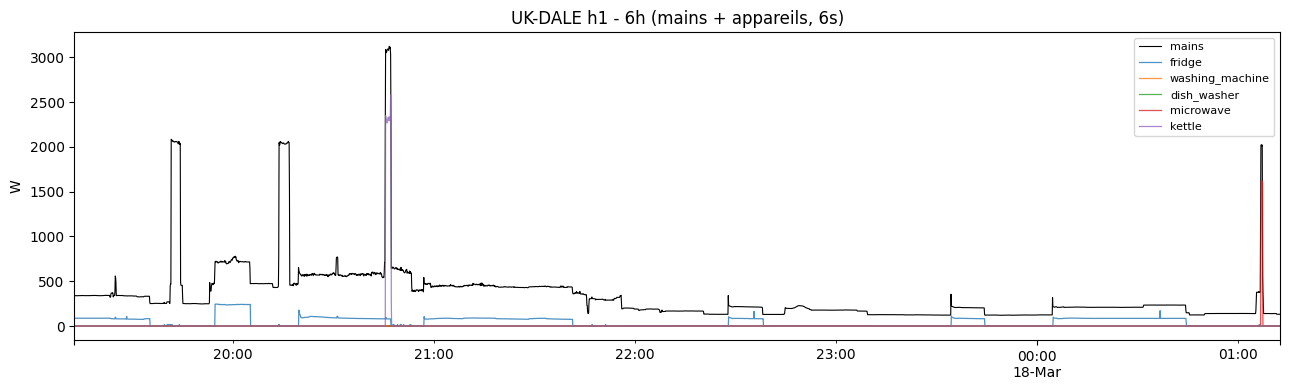

In [8]:
ex = manifest_A[0]
df = pd.read_pickle(ALIGNED_DIR / f"{ex['dataset']}_house{ex['house']}.pkl").dropna(how="all")
sl = df.iloc[: int(6 * 3600 / TARGET_SAMPLE_PERIOD)]   # ~6 h

fig, ax = plt.subplots(figsize=(13, 4))
sl["mains"].plot(ax=ax, lw=0.8, color="black", label="mains")
for col in sl.columns:
    if col != "mains":
        sl[col].plot(ax=ax, lw=0.9, alpha=0.8, label=col)
ax.set_title(f"{ex['dataset']} h{ex['house']} - 6h (mains + appareils, 6s)")
ax.set_ylabel("W"); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 5 — Étage B : séquences par appareil + offsets de segments

Pour chaque (dataset, split, appareil), on concatène les maisons en séquences 1D de watts,
en ne gardant que les **segments continus sans NaN** (≥ une fenêtre). Les `offsets` marquent
les frontières : le fenêtrage ne traversera jamais un trou ni une frontière entre maisons.

In [9]:
def build_sequences(ds_name, split):
    houses = SPLITS[ds_name][split]
    out = {}
    for canonical in APPLIANCES_BY_DATASET[ds_name]:
        col = COLNAME[canonical]
        mains_parts, target_parts, offsets = [], [], [0]
        for h in houses:
            path = ALIGNED_DIR / f"{ds_name}_house{h}.pkl"
            if not path.exists():
                continue
            df = pd.read_pickle(path)
            if col not in df.columns:
                continue
            pair = df[["mains", col]]
            valid = pair.notna().all(axis=1).values
            mains_v, target_v = pair["mains"].values, pair[col].values
            for s, e in contiguous_segments(valid, MIN_SEGMENT_LEN):
                mains_parts.append(mains_v[s:e])
                target_parts.append(target_v[s:e])
                offsets.append(offsets[-1] + (e - s))
        if not mains_parts:
            continue
        out[canonical] = {
            "mains": np.concatenate(mains_parts).astype(np.float32),
            "target": np.concatenate(target_parts).astype(np.float32),
            "offsets": np.array(offsets, dtype=np.int64),
        }
    return out

manifest_B = []
for ds_name in datasets:
    for split in ("train", "test"):
        seqs = build_sequences(ds_name, split)
        for canonical, d in seqs.items():
            fname = f"{COLNAME[canonical]}__{ds_name}__{split}.npz"
            np.savez_compressed(
                SEQ_DIR / fname,
                mains=d["mains"], target=d["target"], offsets=d["offsets"],
                sample_period=TARGET_SAMPLE_PERIOD, window_size=WINDOW_SIZE,
                on_threshold=ON_POWER_THRESHOLDS[canonical],
                appliance=canonical, dataset=ds_name, split=split,
            )
            n_win = count_windows(d["offsets"], WINDOW_SIZE)
            manifest_B.append({
                "file": fname, "dataset": ds_name, "split": split,
                "appliance": canonical, "n_points": len(d["mains"]),
                "n_segments": len(d["offsets"]) - 1, "n_windows_stride1": int(n_win),
            })
            print(f"  {fname:42s} pts={len(d['mains']):>8d} "
                  f"seg={len(d['offsets'])-1:>4d} win={int(n_win):>8d}")

manifest_B_df = pd.DataFrame(manifest_B)
print("\nEtage B termine.")
manifest_B_df

  fridge__UK-DALE__train.npz                 pts= 2029323 seg= 163 win= 1931849
  washing_machine__UK-DALE__train.npz        pts= 2020776 seg= 166 win= 1921508
  dish_washer__UK-DALE__train.npz            pts= 1183979 seg= 103 win= 1122385
  microwave__UK-DALE__train.npz              pts= 2004739 seg= 208 win= 1880355
  kettle__UK-DALE__train.npz                 pts= 2404628 seg= 177 win= 2298782
  fridge__UK-DALE__test.npz                  pts=  794440 seg= 356 win=  581552
  washing_machine__UK-DALE__test.npz         pts=  825809 seg= 252 win=  675113
  dish_washer__UK-DALE__test.npz             pts=  825810 seg= 252 win=  675114
  microwave__UK-DALE__test.npz               pts=  825810 seg= 252 win=  675114
  kettle__UK-DALE__test.npz                  pts=  863795 seg=  12 win=  856619
  fridge__REDD__train.npz                    pts=  700786 seg=  65 win=  661916
  washing_machine__REDD__train.npz           pts=  702148 seg=  63 win=  664474
  dish_washer__REDD__train.npz          

,file,dataset,split,appliance,n_points,n_segments,n_windows_stride1
0,fridge__UK-DALE__train.npz,UK-DALE,train,fridge,2029323,163,1931849
1,washing_machine__UK-DALE__train.npz,UK-DALE,train,washing machine,2020776,166,1921508
2,dish_washer__UK-DALE__train.npz,UK-DALE,train,dish washer,1183979,103,1122385
3,microwave__UK-DALE__train.npz,UK-DALE,train,microwave,2004739,208,1880355
4,kettle__UK-DALE__train.npz,UK-DALE,train,kettle,2404628,177,2298782
5,fridge__UK-DALE__test.npz,UK-DALE,test,fridge,794440,356,581552
6,washing_machine__UK-DALE__test.npz,UK-DALE,test,washing machine,825809,252,675113
7,dish_washer__UK-DALE__test.npz,UK-DALE,test,dish washer,825810,252,675114
8,microwave__UK-DALE__test.npz,UK-DALE,test,microwave,825810,252,675114
9,kettle__UK-DALE__test.npz,UK-DALE,test,kettle,863795,12,856619


## 6 — Paramètres de normalisation (train uniquement)

Standardisation \(z=(x-\mu)/\sigma\), paramètres calculés **sur les maisons de train** de
chaque dataset (jamais le test → pas de fuite). Sauvegardés en JSON, appliqués à la volée.

In [10]:
def train_stats(ds_name):
    houses = SPLITS[ds_name]["train"]
    frames = [pd.read_pickle(ALIGNED_DIR / f"{ds_name}_house{h}.pkl")
              for h in houses if (ALIGNED_DIR / f"{ds_name}_house{h}.pkl").exists()]
    if not frames:
        return None
    big = pd.concat(frames, axis=0)
    stats = {"mains": {"mean": float(big["mains"].mean()), "std": float(big["mains"].std())}}
    apps = {}
    for canonical in APPLIANCES_BY_DATASET[ds_name]:
        col = COLNAME[canonical]
        if col in big.columns and big[col].notna().any():
            apps[canonical] = {"mean": float(big[col].mean()), "std": float(big[col].std())}
    stats["appliances"] = apps
    return stats

norm_params = {}
for ds_name in datasets:
    s = train_stats(ds_name)
    if s is not None:
        norm_params[ds_name] = s

with open(PROC_DIR / "norm_params.json", "w") as f:
    json.dump(norm_params, f, indent=2)

print("Sauvegarde :", PROC_DIR / "norm_params.json")
print(json.dumps(norm_params, indent=2))

Sauvegarde : ..\data\processed\norm_params.json
{
  "UK-DALE": {
    "mains": {
      "mean": 374.3258056640625,
      "std": 519.8279418945312
    },
    "appliances": {
      "fridge": {
        "mean": 35.06415939331055,
        "std": 50.523136138916016
      },
      "washing machine": {
        "mean": 21.50249481201172,
        "std": 180.75282287597656
      },
      "dish washer": {
        "mean": 26.74853515625,
        "std": 227.20338439941406
      },
      "microwave": {
        "mean": 12.813669204711914,
        "std": 137.55343627929688
      },
      "kettle": {
        "mean": 23.8038330078125,
        "std": 248.0454864501953
      }
    }
  },
  "REDD": {
    "mains": {
      "mean": 361.21484375,
      "std": 657.30224609375
    },
    "appliances": {
      "fridge": {
        "mean": 58.765769958496094,
        "std": 83.67408752441406
      },
      "washing machine": {
        "mean": 42.64082717895508,
        "std": 380.8405456542969
      },
      "dish was

## 7 — Fenêtrage à la volée : démonstration et contrôle

Vérification que le fenêtrage Seq2Point fonctionne sur les séquences sauvegardées. C'est la
logique que reprendra le `Dataset` PyTorch (notebook 04), sans matérialiser les fenêtres.

Segment 0 : 22843 points -> X=(22245, 599), y=(22245,)
Total fenetres (stride 1, tous segments) : 1,931,849


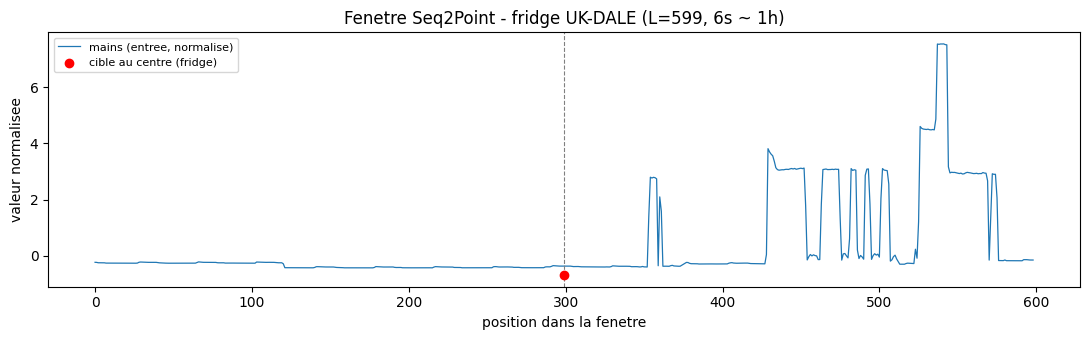

In [11]:
demo_ds, demo_split, demo_app = "UK-DALE", "train", "fridge"
npz = np.load(SEQ_DIR / f"{COLNAME[demo_app]}__{demo_ds}__{demo_split}.npz", allow_pickle=True)
mains, target, offsets = npz["mains"], npz["target"], npz["offsets"]

mu_m = norm_params[demo_ds]["mains"]["mean"]; sd_m = norm_params[demo_ds]["mains"]["std"]
mu_a = norm_params[demo_ds]["appliances"][demo_app]["mean"]
sd_a = norm_params[demo_ds]["appliances"][demo_app]["std"]

s0, e0 = offsets[0], offsets[1]
Xn = (mains[s0:e0] - mu_m) / sd_m
yn = (target[s0:e0] - mu_a) / sd_a
X, y = windows_from_segment(Xn, yn, WINDOW_SIZE)
print(f"Segment 0 : {e0 - s0} points -> X={X.shape}, y={y.shape}")
print(f"Total fenetres (stride 1, tous segments) : {count_windows(offsets, WINDOW_SIZE):,}")

k = len(X) // 3
half = WINDOW_SIZE // 2
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(X[k], lw=0.9, label="mains (entree, normalise)")
ax.axvline(half, color="gray", ls="--", lw=0.8)
ax.scatter([half], [y[k]], color="red", zorder=5, label=f"cible au centre ({demo_app})")
ax.set_title(f"Fenetre Seq2Point - {demo_app} {demo_ds} (L={WINDOW_SIZE}, 6s ~ 1h)")
ax.set_xlabel("position dans la fenetre"); ax.set_ylabel("valeur normalisee")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 8 — Manifeste des artefacts

In [12]:
manifest = {
    "params": {
        "target_sample_period_s": TARGET_SAMPLE_PERIOD,
        "window_size": WINDOW_SIZE,
        "max_days_per_house": MAX_DAYS_PER_HOUSE,
        "min_segment_len": MIN_SEGMENT_LEN,
        "on_power_thresholds": ON_POWER_THRESHOLDS,
        "appliance_aliases": APPLIANCE_ALIASES,
        "splits": SPLITS,
        "appliances_by_dataset": APPLIANCES_BY_DATASET,
    },
    "aligned_frames": manifest_A,
    "sequences": manifest_B,
    "norm_params_file": str((PROC_DIR / "norm_params.json").as_posix()),
}
with open(PROC_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print("Manifeste :", PROC_DIR / "manifest.json")
print("Sequences produites :", len(manifest_B), "| Frames alignes :", len(manifest_A))
for p in sorted(SEQ_DIR.glob("*.npz")):
    print(f"  {p.name:42s} {p.stat().st_size/1e6:6.1f} Mo")

Manifeste : ..\data\processed\manifest.json
Sequences produites : 18 | Frames alignes : 9
  dish_washer__REDD__test.npz                   1.1 Mo
  dish_washer__REDD__train.npz                  2.2 Mo
  dish_washer__UK-DALE__test.npz                2.6 Mo
  dish_washer__UK-DALE__train.npz               3.7 Mo
  fridge__REDD__test.npz                        0.2 Mo
  fridge__REDD__train.npz                       2.5 Mo
  fridge__UK-DALE__test.npz                     2.7 Mo
  fridge__UK-DALE__train.npz                    5.0 Mo
  kettle__UK-DALE__test.npz                     2.7 Mo
  kettle__UK-DALE__train.npz                    5.9 Mo
  microwave__REDD__test.npz                     0.2 Mo
  microwave__REDD__train.npz                    2.2 Mo
  microwave__UK-DALE__test.npz                  2.7 Mo
  microwave__UK-DALE__train.npz                 4.7 Mo
  washing_machine__REDD__test.npz               1.1 Mo
  washing_machine__REDD__train.npz              2.2 Mo
  washing_machine__UK-DALE__te

## 9 — Synthèse

In [13]:
import inspect
print("native_series_rebinned défini ?", "native_series_rebinned" in dir())
print("combine_meters défini ?", "combine_meters" in dir())
print("mains_series défini ?", "mains_series" in dir())
print("---")
print("build_house_frame appelle native ?", "combine_meters" in inspect.getsource(build_house_frame))

native_series_rebinned défini ? True
combine_meters défini ? True
mains_series défini ? True
---
build_house_frame appelle native ? True


In [14]:
ds = datasets["UK-DALE"]
ds.set_window(start=None, end=None)
set_house_window(ds, 1, MAX_DAYS_PER_HOUSE)
elec = ds.buildings[1].elec

# fridge UK-DALE h1 via nos fonctions
meters = resolve_meters(elec, "fridge")
print("meters fridge:", [(m.instance(), [get_app_type(a) for a in m.appliances]) for m in meters])

agg = combine_meters(meters, TARGET_SAMPLE_PERIOD)
print("combine_meters -> type:", type(agg).__name__)
print("  longueur :", len(agg))
print("  NaN      :", round(100*agg.isna().mean(), 2), "%")
print("  index 0-3:", list(agg.index[:3]))
print("  pas median:", agg.index.to_series().diff().median().total_seconds(), "s")

# une seule serie native, avant somme
one = native_series_rebinned(meters[0], TARGET_SAMPLE_PERIOD)
print("\nnative_series_rebinned (meter 0):")
print("  longueur :", len(one))
print("  NaN      :", round(100*one.isna().mean(), 2), "%")
ds.set_window(start=None, end=None)

meters fridge: [(12, ['fridge freezer'])]
combine_meters -> type: Series
  longueur : 864000
  NaN      : 0.93 %
  index 0-3: [Timestamp('2013-03-17 19:12:42+0000', tz='Europe/London'), Timestamp('2013-03-17 19:12:48+0000', tz='Europe/London'), Timestamp('2013-03-17 19:12:54+0000', tz='Europe/London')]
  pas median: 6.0 s

native_series_rebinned (meter 0):
  longueur : 864000
  NaN      : 0.93 %


In [15]:
import torch
print("CUDA dispo :", torch.cuda.is_available())
print("MPS dispo  :", getattr(torch.backends, "mps", None) and torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA dispo : False
MPS dispo  : False


**Artefacts produits :**
- `data/processed/aligned/{dataset}_house{N}.pkl` — frames alignés en watts (cache).
- `data/processed/seq2point/{appliance}__{dataset}__{split}.npz` — séquences 1D + offsets.
- `data/processed/norm_params.json` — μ/σ train par dataset.
- `data/processed/manifest.json` — paramètres + tailles.

**Méthode d'extraction (point technique central).** Extraction à résolution native →
`dropna` → re-bin pandas à 6 s → interpolation linéaire bornée (≤ 18 s) des micro-trous.
Demander directement `sample_period=6` à NILMTK générait des NaN fantômes sur les sections
non contiguës ; l'interpolation bornée comble les micro-coupures d'échantillonnage sans
toucher aux vrais trous longs.

**Qualité des données par maison.**
- UK-DALE h1/h4/h5 : propres (mains et appareils < 5 % de NaN). Terrain principal.
- UK-DALE h2 : mains propre (0,4 %) mais sous-compteurs non-kettle à ~56 % (installation
  partielle) → h2 contribue surtout le kettle au train.
- REDD : enregistrements fragmentés. Mains à ~50 % (h1), ~60 % (h2/h3/h4), ~92 % (h5) de
  pas non couverts en temps calendaire — propriété intrinsèque du dataset, pas un artefact.
  La segmentation (étage B) ne conserve que les sections continues.

**Volume utilisable (étage B).**
- UK-DALE train : 1,2–2,4 M fenêtres/appareil ; test (h5) : 580–860 k. Très confortable.
- REDD train : ~660 k fenêtres/appareil. REDD test mince, surtout fridge/microwave
  (47 k pts, issus de h5 seule) → évaluation REDD à interpréter avec prudence.

**Activations à nos seuils (sur 60 j/maison).**
- fridge : abondant (1 600–2 500/maison UK-DALE) → le plus facile.
- kettle (150–330), washing machine (260–890) : corrects.
- dish washer (80–120) : rare, appareil le plus fragile.
- microwave : modéré, mais test UK-DALE h5 = 14 seulement → F1 peu robuste en test.

**Décisions prises :**
- Regroupement charge froide (fridge + freezer + fridge freezer) — discutable.
- Extraction native + re-bin pandas + interpolation bornée (vs resampling NILMTK direct).
- Normalisation par dataset (la version cross-dataset utilisera les stats du dataset source).
- Cap MAX_DAYS_PER_HOUSE = 60 j — compromis temps/quantité.

**Limites identifiées :**
- REDD : enregistrements fragmentés → moins de données et test peu fourni. UK-DALE reste
  le protocole principal ; REDD sert la validation inter-dataset, à lire avec prudence.
- microwave en test UK-DALE (h5, 14 cycles) : métriques de détection peu robustes.
- Si le dishwasher sous-performe au notebook 04, augmenter MAX_DAYS_PER_HOUSE.